In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

Found 25 simulations


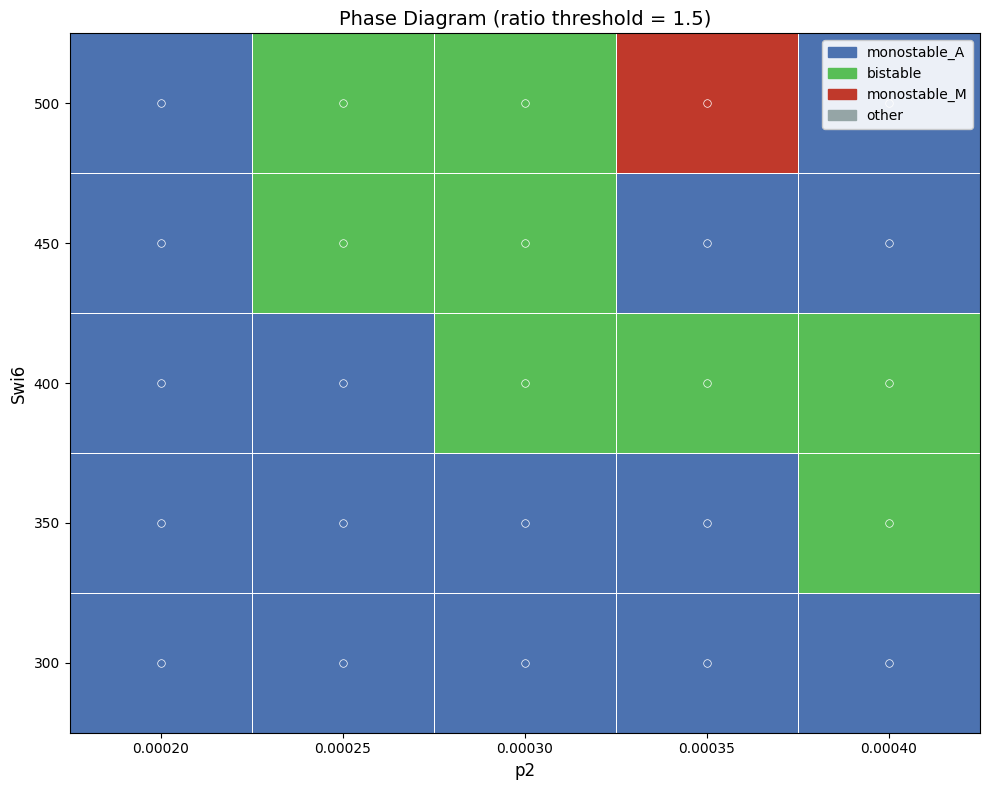

In [16]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import re
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# Define base paths
base_path = Path("/home/xnk400/PhD/Documents/Berard2025/ParameterScanDifferentSwi6Differentp2-15-08")
full_a_path = base_path / "FullA"
full_m_path = base_path / "FullM"

RATIO = 1.5  # tweak this threshold

def extract_parameters(folder_name):
    match = re.search(r'sim_p2_([\d.]+)_noise_([\d.]+)_swi6_([\d.]+)', folder_name)
    if match:
        return {'p2': float(match.group(1)), 'noise': float(match.group(2)), 'swi6': float(match.group(3))}
    return None

def get_means(types_file):
    try:
        df = pd.read_csv(types_file, sep=',', comment='#', header=None, names=['A','U','M','Swi6','Swi6M'])
        return df['A'].mean(), df['M'].mean()
    except Exception as e:
        print(f"Error reading {types_file}: {e}")
        return None, None

# Scan directories
results = []

for full_a_folder in full_a_path.glob("sim_p2_*"):
    if not full_a_folder.is_dir():
        continue

    params = extract_parameters(full_a_folder.name)
    if params is None:
        continue

    full_m_folder = full_m_path / full_a_folder.name
    if not full_m_folder.exists():
        continue

    types_a = full_a_folder / "types1.dat"
    types_m = full_m_folder / "types1.dat"
    if not types_a.exists() or not types_m.exists():
        continue

    mean_A_in_fullA, mean_M_in_fullA = get_means(types_a)
    mean_A_in_fullM, mean_M_in_fullM = get_means(types_m)

    if None in (mean_A_in_fullA, mean_M_in_fullA, mean_A_in_fullM, mean_M_in_fullM):
        continue

    a_stable = mean_A_in_fullA >= RATIO * mean_M_in_fullA
    m_stable = mean_M_in_fullM >= RATIO * mean_A_in_fullM

    if a_stable and m_stable:
        state = 'bistable'
    elif a_stable:
        state = 'monostable_A'
    elif m_stable:
        state = 'monostable_M'
    else:
        state = 'other'

    results.append({'p2': params['p2'], 'swi6': params['swi6'], 'noise': params['noise'], 'state': state})

print(f"Found {len(results)} simulations")

results_df = pd.DataFrame(results)

state_to_num = {'monostable_A': 0, 'bistable': 1, 'monostable_M': 2, 'other': 3}
colors = {
    'monostable_A': '#4C72B0',
    'bistable':     '#58BE56',
    'monostable_M': '#C0392B',
    'other':        '#95A5A6'
}

p2_vals = sorted(results_df['p2'].unique())
sw_vals = sorted(results_df['swi6'].unique())

grid = np.full((len(sw_vals), len(p2_vals)), np.nan)
p2_idx = {v: i for i, v in enumerate(p2_vals)}
sw_idx = {v: i for i, v in enumerate(sw_vals)}

for _, row in results_df.iterrows():
    grid[sw_idx[row['swi6']], p2_idx[row['p2']]] = state_to_num[row['state']]

cmap  = mcolors.ListedColormap([colors[s] for s in state_to_num])
norm  = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

def edges(vals):
    vals = np.array(vals, dtype=float)
    mid  = (vals[:-1] + vals[1:]) / 2
    return np.concatenate([[vals[0] - (mid[0] - vals[0])], mid, [vals[-1] + (vals[-1] - mid[-1])]])

p2_edges = edges(p2_vals)
sw_edges = edges(sw_vals)

fig, ax = plt.subplots(figsize=(10, 8))
ax.pcolormesh(p2_edges, sw_edges, grid, cmap=cmap, norm=norm,
              shading='flat', edgecolors='white', linewidth=0.4)

for state in state_to_num:
    mask = results_df['state'] == state
    ax.scatter(results_df[mask]['p2'], results_df[mask]['swi6'],
               color=colors[state], s=30, zorder=3, edgecolors='white', linewidths=0.5)

patches = [mpatches.Patch(color=colors[s], label=s) for s in state_to_num]
ax.legend(handles=patches, fontsize=10, framealpha=0.9)
ax.set_xlabel('p2', fontsize=12)
ax.set_ylabel('Swi6', fontsize=12)
ax.set_title(f'Phase Diagram (ratio threshold = {RATIO})', fontsize=14)
ax.grid(False)
plt.tight_layout()
plt.savefig("phase_diagram.pdf", dpi=150)
plt.show()

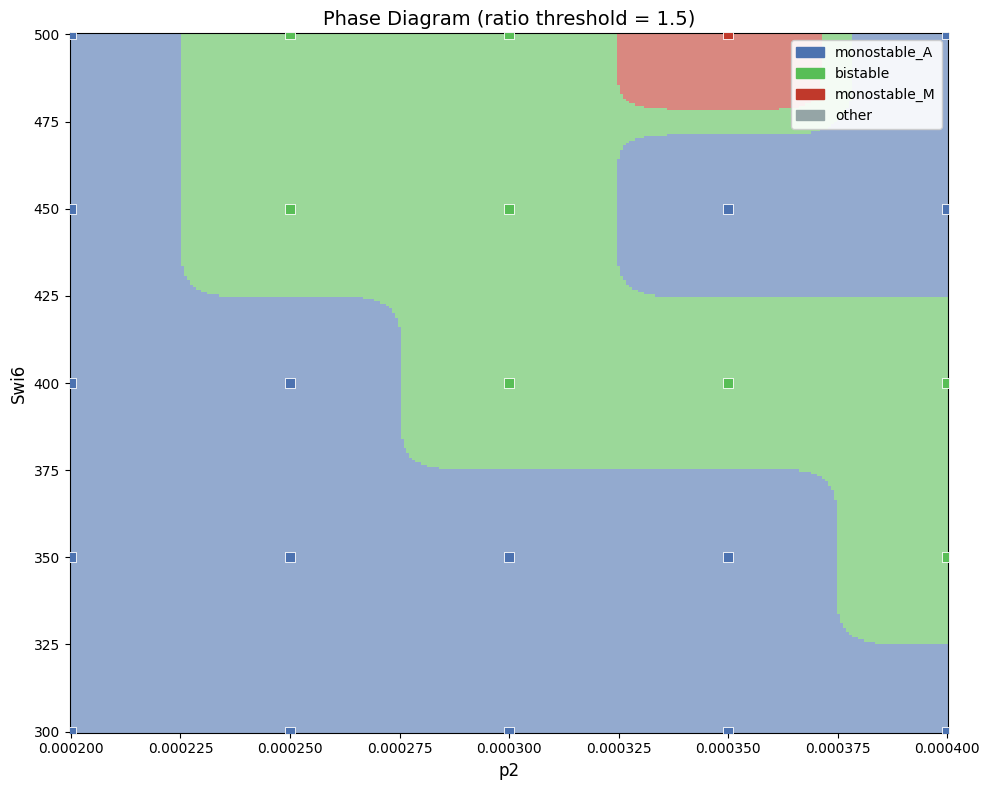

In [20]:
from scipy.interpolate import NearestNDInterpolator
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# ... (keep all the data loading code the same) ...

state_to_num = {'monostable_A': 0, 'bistable': 1, 'monostable_M': 2, 'other': 3}
colors = {
    'monostable_A': '#4C72B0',
    'bistable':     '#58BE56',
    'monostable_M': '#C0392B',
    'other':        '#95A5A6'
}

# ── Smooth background via nearest-neighbour interpolation on fine grid ────────
points = results_df[['p2', 'swi6']].values
values = results_df['state'].map(state_to_num).values

interp = NearestNDInterpolator(points, values)

# Fine grid (increase 300 for smoother result)
p2_fine = np.linspace(results_df['p2'].min(), results_df['p2'].max(), 300)
sw_fine = np.linspace(results_df['swi6'].min(), results_df['swi6'].max(), 300)
P2, SW  = np.meshgrid(p2_fine, sw_fine)
Z       = interp(P2, SW)

# Optional: apply Gaussian blur to soften edges
from scipy.ndimage import gaussian_filter
Z_smooth = gaussian_filter(Z.astype(float), sigma=8)  # increase sigma for smoother

cmap = mcolors.ListedColormap([colors[s] for s in state_to_num])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig, ax = plt.subplots(figsize=(10, 8))

# Smooth background
ax.pcolormesh(p2_fine, sw_fine, Z_smooth, cmap=cmap, norm=norm,
              shading='auto', alpha=0.6)

# Simulation dots on top
for state, num in state_to_num.items():
    mask = results_df['state'] == state
    ax.scatter(results_df[mask]['p2'], results_df[mask]['swi6'],
               color=colors[state], s=60, zorder=3,
               edgecolors='white', linewidths=0.6, marker='s')  # 's' = square

patches = [mpatches.Patch(color=colors[s], label=s) for s in state_to_num]
ax.legend(handles=patches, fontsize=10, framealpha=0.9)
ax.set_xlabel('p2', fontsize=12)
ax.set_ylabel('Swi6', fontsize=12)
ax.set_title(f'Phase Diagram (ratio threshold = {RATIO})', fontsize=14)
ax.grid(False)
plt.tight_layout()
plt.savefig("phase_diagram.pdf", dpi=150)
plt.show()